In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Remove rows with no product description
df = df.dropna(subset=["Description"])

# Remove cancelled orders (invoice numbers starting with "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only positive quantities
df = df[df["Quantity"] > 0]

# Remove extra spaces from product names
df["Description"] = df["Description"].str.strip()

print(df.shape)

(530693, 8)


In [4]:
basket = (df[df["Country"] == "France"]
          .groupby(["InvoiceNo", "Description"])["Quantity"]
          .sum()
          .unstack()
          .fillna(0))

# Convert quantities to True/False: was the item in the basket or not?
basket_bool = basket > 0

print(basket_bool.shape)

(392, 1563)


In [5]:
from mlxtend.frequent_patterns import apriori, association_rules

# Find item combinations appearing in at least 5% of baskets
frequent_items = apriori(basket_bool, min_support=0.05, use_colnames=True)

# Generate "if X then Y" rules from those combinations
rules = association_rules(frequent_items, metric="lift", min_threshold=1)
rules = rules.sort_values("lift", ascending=False)

rules.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
87,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.063776,0.056122,0.051020,0.800000,14.254545,1.0,0.047441,4.719388,0.993188,0.740741,0.788108,0.854545
86,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.056122,0.063776,0.051020,0.909091,14.254545,1.0,0.047441,10.298469,0.985135,0.740741,0.902898,0.854545
25,(CHILDRENS CUTLERY DOLLY GIRL),(CHILDRENS CUTLERY SPACEBOY),0.071429,0.068878,0.063776,0.892857,12.962963,1.0,0.058856,8.690476,0.993846,0.833333,0.884932,0.909392
24,(CHILDRENS CUTLERY SPACEBOY),(CHILDRENS CUTLERY DOLLY GIRL),0.068878,0.071429,0.063776,0.925926,12.962963,1.0,0.058856,12.535714,0.991123,0.833333,0.920228,0.909392
307,"(ALARM CLOCK BAKELIKE PINK, POSTAGE, ALARM CLO...",(ALARM CLOCK BAKELIKE RED),0.061224,0.094388,0.056122,0.916667,9.711712,1.0,0.050344,10.867347,0.955534,0.564103,0.907981,0.755631
318,(ALARM CLOCK BAKELIKE RED),"(ALARM CLOCK BAKELIKE PINK, POSTAGE, ALARM CLO...",0.094388,0.061224,0.056122,0.594595,9.711712,1.0,0.050344,2.315646,0.990525,0.564103,0.568155,0.755631
181,(ALARM CLOCK BAKELIKE RED),"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.094388,0.073980,0.063776,0.675676,9.133271,1.0,0.056793,2.855230,0.983324,0.609756,0.649765,0.768872
176,"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",(ALARM CLOCK BAKELIKE RED),0.073980,0.094388,0.063776,0.862069,9.133271,1.0,0.056793,6.565689,0.961653,0.609756,0.847693,0.768872
314,"(ALARM CLOCK BAKELIKE GREEN, POSTAGE)","(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.084184,0.073980,0.056122,0.666667,9.011494,1.0,0.049895,2.778061,0.970752,0.550000,0.640037,0.712644
311,"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...","(ALARM CLOCK BAKELIKE GREEN, POSTAGE)",0.073980,0.084184,0.056122,0.758621,9.011494,1.0,0.049895,3.794096,0.960055,0.550000,0.736433,0.712644


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
strong_bundles = rules[(rules["confidence"] >= 0.65) & (rules["lift"] > 1)]

print(f"Number of high-confidence bundles found: {len(strong_bundles)}")
strong_bundles[["antecedents", "consequents", "support", "confidence", "lift"]]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of high-confidence bundles found: 146


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
87,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.051020,0.800000,14.254545
86,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.051020,0.909091,14.254545
25,(CHILDRENS CUTLERY DOLLY GIRL),(CHILDRENS CUTLERY SPACEBOY),0.063776,0.892857,12.962963
24,(CHILDRENS CUTLERY SPACEBOY),(CHILDRENS CUTLERY DOLLY GIRL),0.063776,0.925926,12.962963
307,"(ALARM CLOCK BAKELIKE PINK, POSTAGE, ALARM CLO...",(ALARM CLOCK BAKELIKE RED),0.056122,0.916667,9.711712
...,...,...,...,...,...
322,"(PLASTERS IN TIN WOODLAND ANIMALS, PLASTERS IN...",(POSTAGE),0.053571,0.777778,1.016296
19,(CHARLOTTE BAG APPLES DESIGN),(POSTAGE),0.053571,0.777778,1.016296
77,(LUNCH BOX I LOVE LONDON),(POSTAGE),0.053571,0.777778,1.016296
156,(SPACEBOY LUNCH BOX),(POSTAGE),0.096939,0.775510,1.013333


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

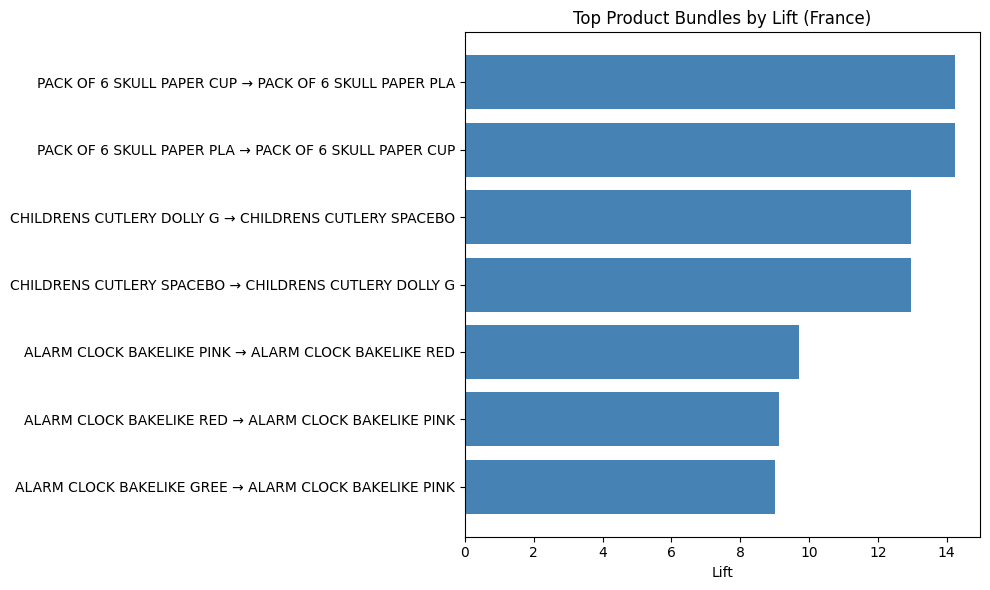

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
import matplotlib.pyplot as plt

top = strong_bundles.head(8).copy()
top["rule"] = top["antecedents"].apply(lambda x: list(x)[0]).str[:25] + " → " + \
              top["consequents"].apply(lambda x: list(x)[0]).str[:25]

plt.figure(figsize=(10, 6))
plt.barh(top["rule"], top["lift"], color="steelblue")
plt.xlabel("Lift")
plt.title("Top Product Bundles by Lift (France)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_bundles.png", dpi=150)
plt.show()

In [8]:
rules_export = rules.copy()
rules_export["antecedents"] = rules_export["antecedents"].apply(lambda x: ", ".join(x))
rules_export["consequents"] = rules_export["consequents"].apply(lambda x: ", ".join(x))
rules_export.to_csv("association_rules.csv", index=False)

print("Saved: association_rules.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: association_rules.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag